<a href="https://colab.research.google.com/github/tanujapawar203/test-/blob/main/Student_Dropout_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive/MyDrive")


['Colab Notebooks',
 'Copy of C2M1_PracticeLab_1_DJing_with_data_Part1.gsheet',
 'Copy of C2M1_Demo_5_start_Lending_Tree_loans_correlations.gsheet',
 'Copy of C2M1_PracticeLab_4_DJing_with_data_Part3.gsheet',
 'Experiment 1 mdm.gdoc',
 'Copy of C2M1_Demo_7_start_pivot_table.gsheet',
 'Copy of C2M2_PracticeLab_1_DJing_with_data_follow_up_Part1.gsheet',
 'Saved from the Google app',
 '2310022_TY_FC.pdf',
 'Infosys spring .pdf',
 'Portfolio.gsite',
 'student-mat.csv']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df.shape
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
df['Dropout'] = np.where((df['absences'] > 10) & (df['G3'] < 10), 1, 0)
df['Dropout'].value_counts()


,count
Dropout,
0,365
1,30


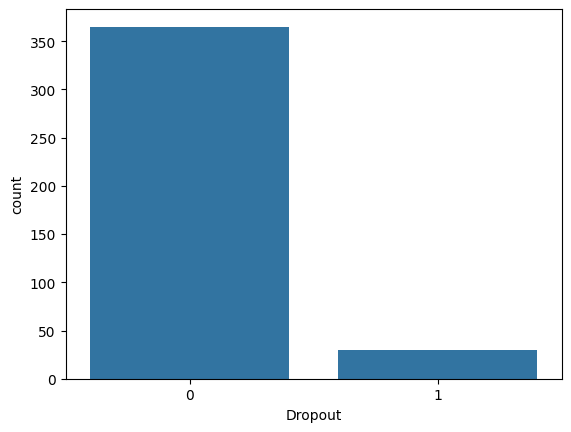

In [ ]:
sns.countplot(x='Dropout', data=df)
plt.show()


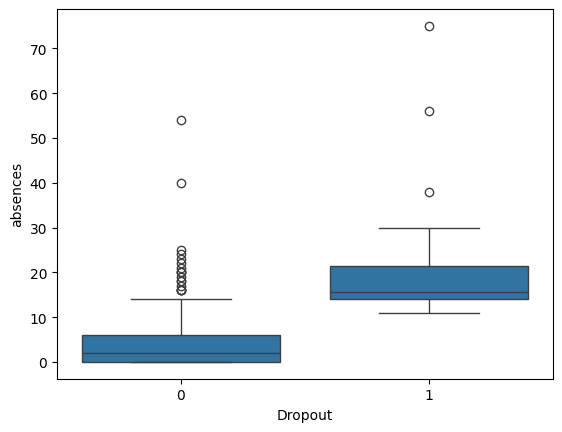

In [ ]:
sns.boxplot(x='Dropout', y='absences', data=df)
plt.show()


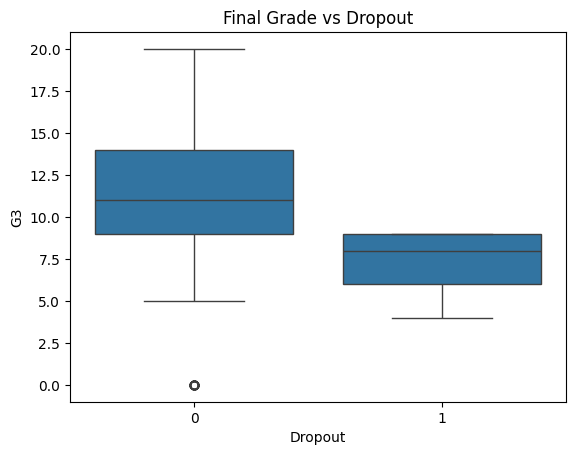

In [ ]:
sns.boxplot(x='Dropout', y='G3', data=df)
plt.title("Final Grade vs Dropout")
plt.show()

In [ ]:
#encoding categorical columns
cat_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [ ]:
#x and y selection
X = df_encoded.drop(["Dropout", "G3", "absences"], axis=1)
y = df_encoded["Dropout"]


In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
#scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))


Logistic Regression Accuracy: 0.7563025210084033
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       110
           1       0.14      0.44      0.22         9

    accuracy                           0.76       119
   macro avg       0.54      0.61      0.54       119
weighted avg       0.88      0.76      0.81       119



In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))


KNN Accuracy: 0.9243697478991597
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       110
           1       0.00      0.00      0.00         9

    accuracy                           0.92       119
   macro avg       0.46      0.50      0.48       119
weighted avg       0.85      0.92      0.89       119



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#SVM
from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight="balanced")
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))


SVM Accuracy: 0.907563025210084
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       110
           1       0.00      0.00      0.00         9

    accuracy                           0.91       119
   macro avg       0.46      0.49      0.48       119
weighted avg       0.85      0.91      0.88       119



In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))


Decision Tree Accuracy: 0.907563025210084
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       110
           1       0.25      0.11      0.15         9

    accuracy                           0.91       119
   macro avg       0.59      0.54      0.55       119
weighted avg       0.88      0.91      0.89       119



In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


Random Forest Accuracy: 0.9243697478991597
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       110
           1       0.00      0.00      0.00         9

    accuracy                           0.92       119
   macro avg       0.46      0.50      0.48       119
weighted avg       0.85      0.92      0.89       119



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#XGBoost
!pip -q install xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))


XGBoost Accuracy: 0.907563025210084
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       110
           1       0.00      0.00      0.00         9

    accuracy                           0.91       119
   macro avg       0.46      0.49      0.48       119
weighted avg       0.85      0.91      0.88       119



In [ ]:
#Comparision of all models
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": pred_lr,
    "KNN": pred_knn,
    "SVM": pred_svm,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "XGBoost": pred_xgb
}

results = []
for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.756303,0.142857,0.444444,0.216216
3,Decision Tree,0.907563,0.250000,0.111111,0.153846
1,KNN,0.924370,0.000000,0.000000,0.000000
2,SVM,0.907563,0.000000,0.000000,0.000000
4,Random Forest,0.924370,0.000000,0.000000,0.000000
5,XGBoost,0.907563,0.000000,0.000000,0.000000


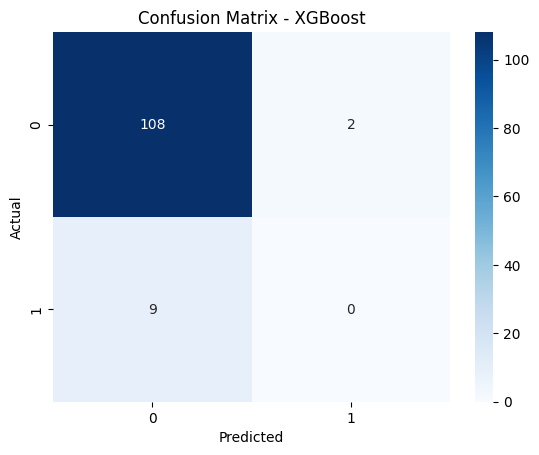

In [ ]:
#Confusion matrix for XGBoost
cm = confusion_matrix(y_test, pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


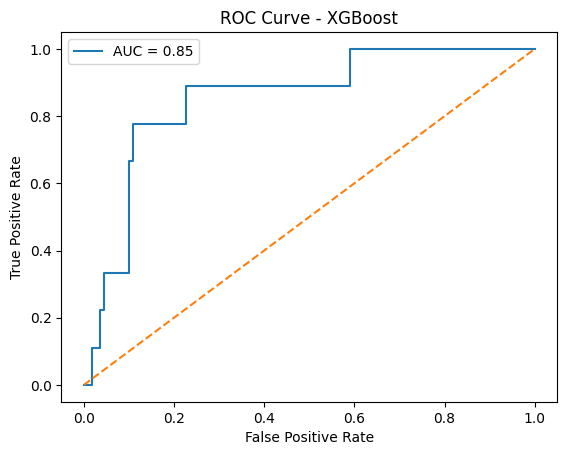

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

y_proba = xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


In [ ]:
#Feature Importance (XGBoost){To explain why dropout happens}
importances = xgb.feature_importances_

feature_names = X.columns
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(10)

feat_imp


,Feature,Importance
13,G2,0.143942
0,age,0.076170
4,studytime,0.062534
9,Dalc,0.060349
29,reason_reputation,0.055579
15,sex_M,0.051102
11,health,0.046236
7,freetime,0.040057
8,goout,0.035607
20,Mjob_other,0.033767


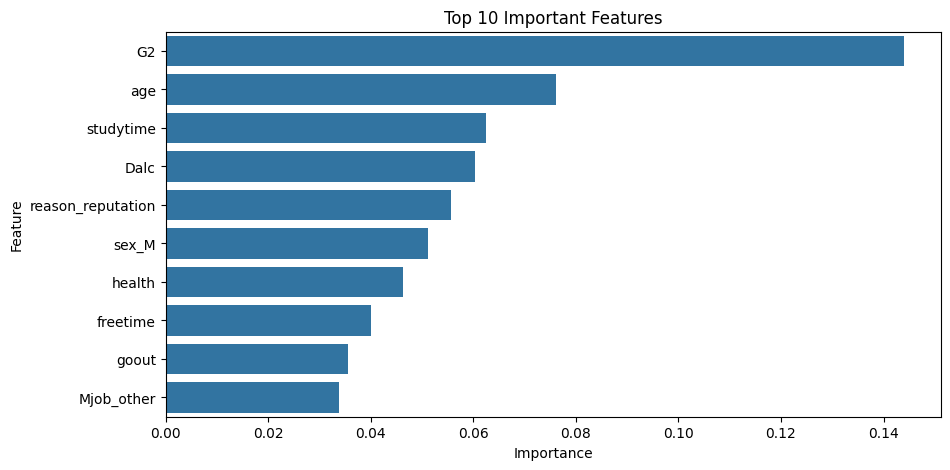

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Top 10 Important Features")
plt.show()


In [ ]:
import os

save_path = "/content/drive/MyDrive/Datasets"
os.makedirs(save_path, exist_ok=True)

import joblib
joblib.dump(xgb, save_path + "/dropout_model.pkl")
joblib.dump(scaler, save_path + "/scaler.pkl")

print("✅ Model saved successfully in Drive:", save_path)


✅ Model saved successfully in Drive: /content/drive/MyDrive/Datasets
